<a href="https://colab.research.google.com/github/AllanFabricio/linear_regression_water_quality_aracaju/blob/main/linear_regression_water_quality_aracaju_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Linear
Neste notebook, vamos pesquisar os fundamentos da regressão linear usando dados ambientais da cidade de Aracaju. A regressão linear é uma das ferramentas mais simples e poderosas no arsenal da ciência de dados, tornando-a uma escolha perfeita para investigar causas e efeitos na natureza.

Nosso objetivo é responder à pergunta: **Existe um relacionamento linear que me permita prever o resultado da balneabilidade em função da precipitação?**

Fluxo da pesquisa:
1. Preparar e limpar dados reais do INMET e ADEMA;
2. Visualizar o relacionamento entre as variáveis através do gráfico de dispersão (scatter plot);
3. Entender a intuição por trás da regressão linear;
4. Implementar uma regressão linear simples e com múltiplas variáveis;
5. Interpretar os resultados e construir um modelo preditivo na prática.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for our plots
sns.set_style('whitegrid')

### Carregando e Preparando os Dados
Vamos carregar os dados diretamente dos arquivos CSV locais.

Temos dois desafios de limpeza aqui:
1. O INMET tem dados diários e a ADEMA tem dados semanais. Precisamos juntar (merge) as duas tabelas usando a data.
2. Os dados brasileiros usam vírgula (`,`) como separador decimal e possuem marcações de falta de dados (como `null` ou `***`) que precisam ser tratadas.

In [4]:
# 1. Carregando os dados do INMET (Pulando as 10 linhas de cabeçalho descritivo)
df_inmet = pd.read_csv('dados_A409_D_2025-01-01_2025-12-31.csv', sep=';', skiprows=10)

# 2. Carregando os dados da ADEMA
df_adema = pd.read_csv('balneabilidade_padrao_inmet.csv', sep=';', skiprows=10)

# Limpeza INMET: Substituir 'null' por NaN, vírgulas por pontos e converter para numérico
df_inmet = df_inmet.replace('null', np.nan)
for col in df_inmet.columns:
    if col != 'Data Medicao' and df_inmet[col].dtype == 'object':
        df_inmet[col] = df_inmet[col].str.replace(',', '.').astype(float)

# Limpeza ADEMA: Substituir '***' por NaN e converter colunas para numérico
df_adema = df_adema.replace('***', np.nan)

# Identificar dinamicamente todas as colunas de praias (tudo exceto a data)
colunas_praias = [c for c in df_adema.columns if c != 'Data Medicao']

for col in colunas_praias:
    if df_adema[col].dtype == 'object':
        df_adema[col] = df_adema[col].str.replace(',', '.').astype(float)

# Juntando os dados das duas fontes por data (Inner Join)
df_merged = pd.merge(df_adema, df_inmet, on='Data Medicao', how='inner')
df_merged['Data Medicao'] = pd.to_datetime(df_merged['Data Medicao'])
df_merged = df_merged.set_index('Data Medicao')

# Definição das variáveis climáticas funcionais (evitando as colunas em pane de temperatura)
col_precipitacao = 'PRECIPITACAO TOTAL, DIARIO (AUT)(mm)'
col_vento = 'VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)'
col_umidade = 'UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)'

print(f"Dados combinados com sucesso! Total de registros correspondentes: {len(df_merged)} dias.")
print("\nPraias identificadas para análise:")
for i, praia in enumerate(colunas_praias, 1):
    print(f"{i}. {praia}")

Dados combinados com sucesso! Total de registros correspondentes: 53 dias.

Praias identificadas para análise:
1. AVS003M - Praia de Atalaia Velha – Em frente aos Arcos da Orla – Aju
2. AVS005M - Praia do Banho Doce – Em frente ao Chafariz – Aju
3. AVS006M - Praia do Refúgio – Em frente ao Condomínio Lago Paranoá–Aju
4. AVS008M - Praia do Hawaizinho - Em frente a Praça de Eventos da Orla – Aju
5. AVS010M - Praia do Robalo – Em frente ao Clube do Banco do Brasil AABB – Aju
6. AVS012M - Praia dos Náufragos – Viral – Aju
7. S01024R - Praia dos Artistas – Coroa do Meio em frente ao Novo Farol – Aju
8. Unnamed: 8


### Visualizando o Scatter Plot
Antes de entendermos a regressão linear, vamos visualizar o relacionamento entre as duas variáveis usando um gráfico de dispersão (scatter plot). Isso nos ajuda a entender se pode haver um relacionamento linear que valha a pena modelar.

* O eixo X será a Precipitação (chuva).
* O eixo Y será a Balneabilidade (concentração de coliformes/bactérias).
[texto do link](https://)
Se houver uma relação, esperaríamos que dias com mais chuva (X maior) apresentassem piores índices de balneabilidade (Y maior, mais coliformes lavados para o mar).

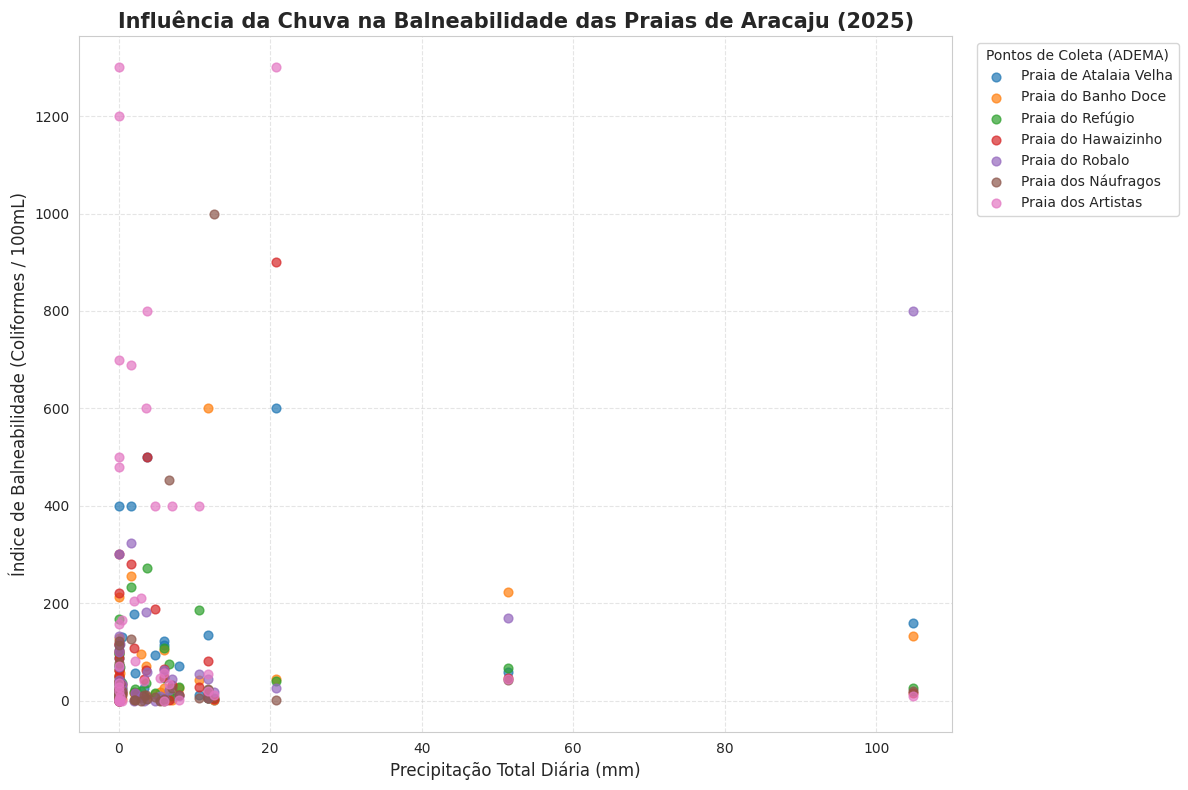

In [5]:
plt.figure(figsize=(12, 8))

# Loop para plotar cada praia individualmente com seus dados válidos
for praia in colunas_praias:
    # Filtra apenas as linhas onde a chuva E a praia específica possuem dados numéricos
    dados_praia = df_merged[[col_precipitacao, praia]].dropna()

    if not dados_praia.empty:
        # Extrai um nome mais curto para a legenda não poluir o gráfico
        nome_exibicao = praia.split(' - ')[1].split(' – ')[0] if ' - ' in praia else praia

        plt.scatter(dados_praia[col_precipitacao], dados_praia[praia], alpha=0.7, label=nome_exibicao, s=40)

plt.title('Influência da Chuva na Balneabilidade das Praias de Aracaju (2025)', fontsize=15, fontweight='bold')
plt.xlabel('Precipitação Total Diária (mm)', fontsize=12)
plt.ylabel('Índice de Balneabilidade (Coliformes / 100mL)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Posiciona a legenda do lado de fora para melhor visualização
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Pontos de Coleta (ADEMA)")
plt.tight_layout()
plt.show()

### Calculando a Regressão Linear
A regressão linear consiste em encontrar a linha reta de "melhor ajuste" através desse conjunto de pontos.

**Intuição**
O objetivo da regressão linear é desenhar uma linha reta que esteja o mais próximo possível de todos os pontos de chuva e balneabilidade.
A equação dessa linha é:
$$Y = \beta X + \alpha$$

Onde:
* $Y$ é a variável dependente (o que prevemos: Balneabilidade)
* $X$ é a variável independente (o que usamos para prever: Precipitação)
* $\beta$ é a inclinação (quanto a balneabilidade piora quando chove 1mm a mais)
* $\alpha$ é a constante (qual é a balneabilidade esperada num dia sem chuva, $X=0$)

In [9]:
from sklearn.linear_model import LinearRegression

col_precipitacao = 'PRECIPITACAO TOTAL, DIARIO (AUT)(mm)'

# 1. Vamos "derreter" o DataFrame para alinhar todas as praias numa única coluna de Balneabilidade
dados_todas_praias = df_merged.reset_index().melt(
    id_vars=['Data Medicao', col_precipitacao],
    value_vars=colunas_praias,
    var_name='Praia',
    value_name='Balneabilidade'
)

# 2. Renomear para facilitar e remover os valores nulos (NaN)
dados_simples = dados_todas_praias.rename(columns={col_precipitacao: 'Precipitacao'})
dados_simples = dados_simples.dropna(subset=['Precipitacao', 'Balneabilidade'])

# 3. Preparar os dados para o scikit-learn
X = dados_simples['Precipitacao'].values.reshape(-1, 1)  # Variável Independente (Chuva)
y = dados_simples['Balneabilidade'].values               # Variável Dependente (Coliformes - Todas as praias)

print(f"Quantidade total de amostras (todas as praias combinadas): {len(X)} medições válidas.")

# Criar e treinar (fit) o modelo de regressão linear global
model = LinearRegression()
model.fit(X, y)

# Obter a inclinação (slope) e a constante (intercept)
best_slope = model.coef_[0]
best_intercept = model.intercept_

print(f"Equação da Regressão (Aracaju): Balneabilidade = {best_slope:.4f} × Precipitação + {best_intercept:.4f}")

Quantidade total de amostras (todas as praias combinadas): 279 medições válidas.
Equação da Regressão (Aracaju): Balneabilidade = 0.9749 × Precipitação + 90.6051


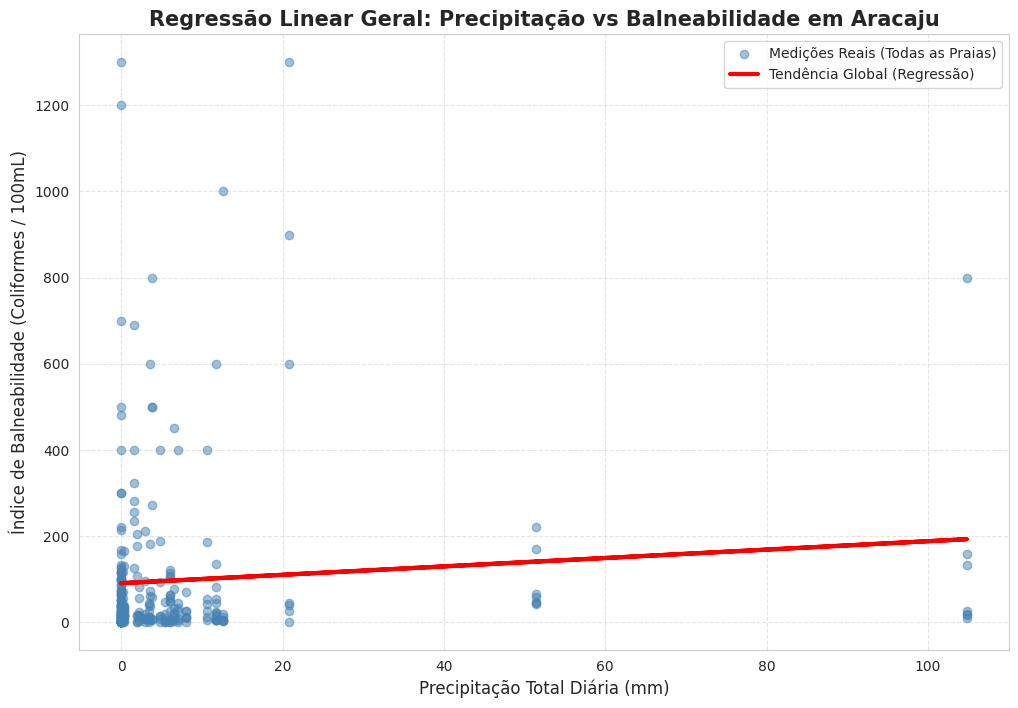

In [10]:
# Fazer predições usando nosso modelo treinado para desenhar a linha
y_pred = model.predict(X)

# Criar o gráfico
plt.figure(figsize=(12, 8))

# Plotar todos os pontos (usamos um alpha menor para lidar com a sobreposição de muitos pontos)
plt.scatter(X, y, alpha=0.5, label='Medições Reais (Todas as Praias)', color='steelblue')

# Plotar a linha de tendência (Regressão)
plt.plot(X, y_pred, color='red', linewidth=3, label='Tendência Global (Regressão)')

plt.title('Regressão Linear Geral: Precipitação vs Balneabilidade em Aracaju', fontsize=15, fontweight='bold')
plt.xlabel('Precipitação Total Diária (mm)', fontsize=12)
plt.ylabel('Índice de Balneabilidade (Coliformes / 100mL)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Entendendo os Resíduos e o Mínimo Erro
Como sabemos que a linha vermelha acima é a "melhor"?
A regressão linear minimiza os "resíduos", que são as distâncias verticais entre o que aconteceu na vida real e o que a nossa linha vermelha tentou prever.

Vamos visualizar o Método dos Mínimos Quadrados (OLS), verificando como diferentes combinações de Inclinação e Constante resultam em erros maiores, e como o nosso modelo encontrou exatamente o fundo do "poço" de erros (o menor erro possível).

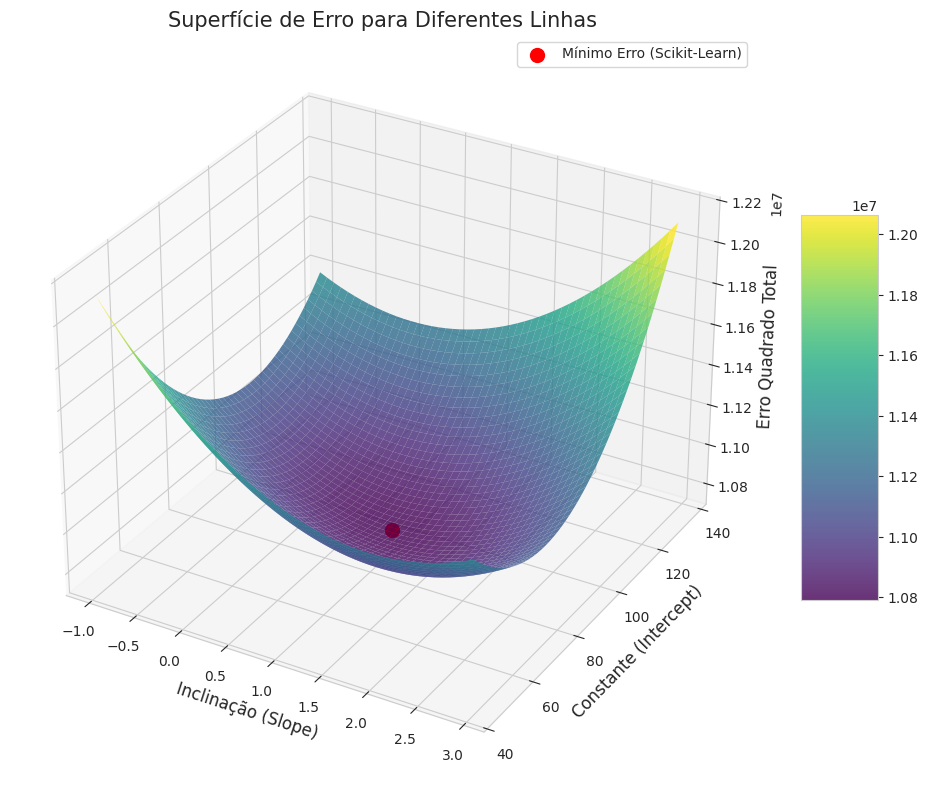

In [11]:
# Função para calcular o erro quadrado total de uma linha
def calculate_squared_error(slope, intercept, X, y):
    predictions = slope * X + intercept
    residuals = y - predictions
    return np.sum(residuals ** 2)

# Grid de valores em volta da melhor solução encontrada pelo scikit-learn
margin_slope = abs(best_slope * 2) if best_slope != 0 else 1.0
margin_int = abs(best_intercept * 0.5) if best_intercept != 0 else 10.0

fine_slopes = np.linspace(best_slope - margin_slope, best_slope + margin_slope, 50)
fine_intercepts = np.linspace(best_intercept - margin_int, best_intercept + margin_int, 50)

error_grid = np.zeros((len(fine_slopes), len(fine_intercepts)))

for i, slope in enumerate(fine_slopes):
    for j, intercept in enumerate(fine_intercepts):
        error_grid[i, j] = calculate_squared_error(slope, intercept, X.flatten(), y)

slope_grid, intercept_grid = np.meshgrid(fine_slopes, fine_intercepts)

# Visualizando em 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(slope_grid, intercept_grid, error_grid.T,
                      cmap='viridis', alpha=0.8, edgecolor='none')

ax.scatter([best_slope], [best_intercept],
           [calculate_squared_error(best_slope, best_intercept, X.flatten(), y)],
           color='red', s=100, label='Mínimo Erro (Scikit-Learn)')

ax.set_xlabel('Inclinação (Slope)', fontsize=12)
ax.set_ylabel('Constante (Intercept)', fontsize=12)
ax.set_zlabel('Erro Quadrado Total', fontsize=12)
ax.set_title('Superfície de Erro para Diferentes Linhas', fontsize=15)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.legend()
plt.show()

### Analisando o Modelo
Visualmente o modelo parece fazer sentido, mas precisamos de métricas matemáticas:
* **R-quadrado (R²)**: Varia de 0 a 1. Mede quanto da variabilidade da balneabilidade pode ser explicada *apenas* pela chuva do dia.
* **MSE**: A média dos erros ao quadrado.
*texto em itálico*
Para simular o mundo real, vamos treinar com dados antigos (80%) e prever o futuro (20%).

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

# Dividindo 80% treino e 20% teste (AGORA USANDO dados_simples)
train_size = int(len(dados_simples) * 0.8)
train_data = dados_simples.iloc[:train_size]
test_data = dados_simples.iloc[train_size:]

X_train = train_data['Precipitacao'].values.reshape(-1, 1)
y_train = train_data['Balneabilidade'].values

X_test = test_data['Precipitacao'].values.reshape(-1, 1)
y_test = test_data['Balneabilidade'].values

# Treinando
model = LinearRegression()
model.fit(X_train, y_train)

# Prevendo no conjunto de teste
y_pred_test = model.predict(X_test)

test_r2 = r2_score(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)

print(f"R-quadrado (R²) no Teste: {test_r2:.4f}")
print(f"Erro Quadrático Médio (MSE) no Teste: {test_mse:.4f}")

R-quadrado (R²) no Teste: -0.1600
Erro Quadrático Médio (MSE) no Teste: 137959.5853


### Indo Além: Regressão Linear Múltipla
Até agora, usamos apenas a chuva do dia para prever a poluição da praia. Na realidade, a água do mar é influenciada por vários fatores simultâneos (ventos que trazem a maré, temperatura que facilita a proliferação bacteriana, etc).

Vamos criar uma **Regressão Linear Múltipla**, adicionando a `Velocidade do Vento` e a `Temperatura Média` aos nossos preditores, e ver se o modelo fica mais preciso (aumento do R²).

In [17]:
# 1. Definindo as colunas do INMET
col_precipitacao = 'PRECIPITACAO TOTAL, DIARIO (AUT)(mm)'
col_vento = 'VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)'
col_umidade = 'UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)'

features_inmet = [col_precipitacao, col_vento, col_umidade]

# 2. "Derreter" o DataFrame mantendo as três variáveis climáticas atreladas a todas as praias
dados_multi_todas = df_merged.reset_index().melt(
    id_vars=['Data Medicao'] + features_inmet,
    value_vars=colunas_praias,
    var_name='Praia',
    value_name='Balneabilidade'
)

# 3. Renomear para facilitar e limpar linhas com qualquer dado vazio
dados_multi_todas = dados_multi_todas.rename(columns={
    col_precipitacao: 'Precipitacao',
    col_vento: 'Vento',
    col_umidade: 'Umidade'
})

features_finais = ['Precipitacao', 'Vento', 'Umidade']
dados_multi_todas = dados_multi_todas.dropna(subset=features_finais + ['Balneabilidade'])

# 4. Divisão de treino (80%) e teste (20%) GLOBAL
train_size_multi = int(len(dados_multi_todas) * 0.8)
train_multi = dados_multi_todas.iloc[:train_size_multi]
test_multi = dados_multi_todas.iloc[train_size_multi:]

X_train_multi = train_multi[features_finais].values
y_train_multi = train_multi['Balneabilidade'].values

X_test_multi = test_multi[features_finais].values
y_test_multi = test_multi['Balneabilidade'].values

print(f"Treinando com todas as praias! Total: {len(X_train_multi)} amostras de treino e {len(X_test_multi)} de teste.\n")

# 5. Treinar o modelo múltiplo global
multi_model = LinearRegression()
multi_model.fit(X_train_multi, y_train_multi)

# Predições e Métricas Globais
y_pred_multi = multi_model.predict(X_test_multi)
multi_r2 = r2_score(y_test_multi, y_pred_multi)
multi_mse = mean_squared_error(y_test_multi, y_pred_multi)

print("Coeficientes da Regressão Múltipla (Impacto na Orla Inteira):")
print(f"Chuva (Precipitação): {multi_model.coef_[0]:.4f}")
print(f"Velocidade do Vento: {multi_model.coef_[1]:.4f}")
print(f"Umidade Relativa: {multi_model.coef_[2]:.4f}")
print(f"Constante (Intercept): {multi_model.intercept_:.4f}")
print(f"\nNovo R-quadrado (R²) Global: {multi_r2:.4f}")

Treinando com todas as praias! Total: 223 amostras de treino e 56 de teste.

Coeficientes da Regressão Múltipla (Impacto na Orla Inteira):
Chuva (Precipitação): 1.2666
Velocidade do Vento: 13.7962
Umidade Relativa: 3.8031
Constante (Intercept): -234.0734

Novo R-quadrado (R²) Global: -0.1339


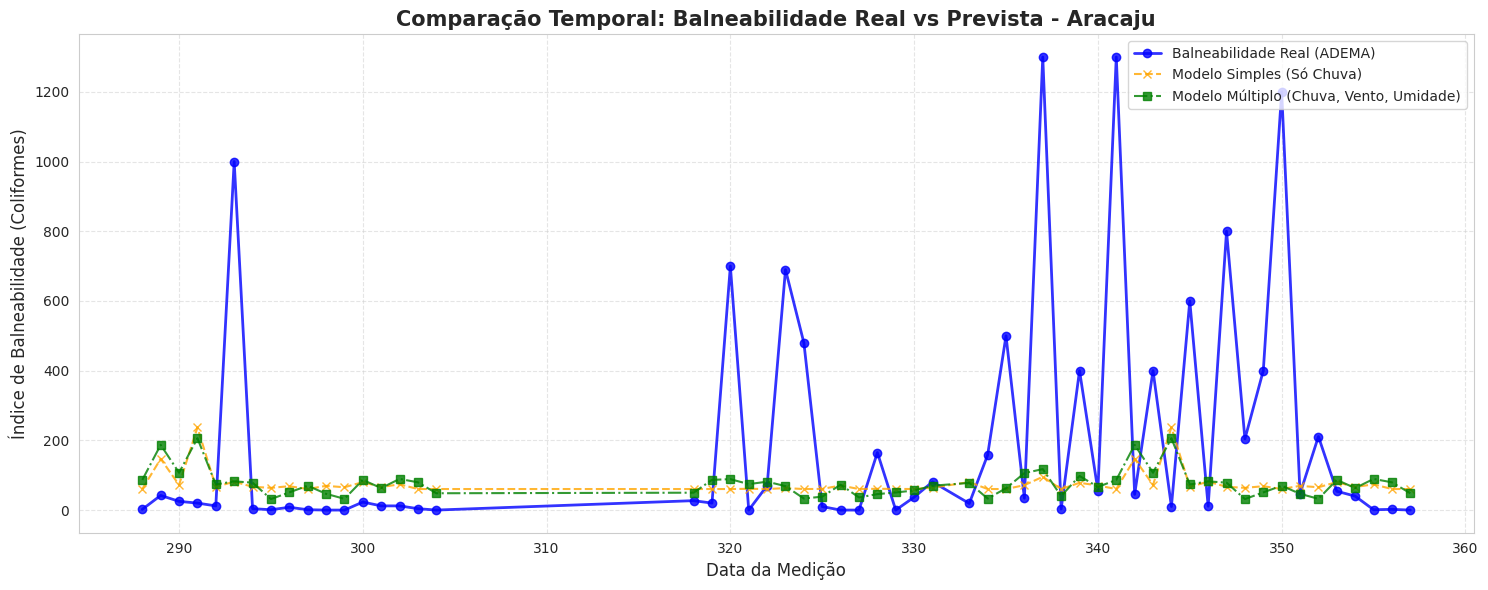

In [21]:
# 1. Para comparar, precisamos fazer o Modelo Simples prever os mesmos dados de teste
# (O modelo simples usa apenas a Chuva, que é a coluna 0 da nossa matriz de teste)
X_test_apenas_chuva = X_test_multi[:, 0].reshape(-1, 1)
y_pred_simples_global = model.predict(X_test_apenas_chuva)

# Aumentamos a largura para 15 para esticar o ziguezague temporal
plt.figure(figsize=(15, 6))

# 2. Gráfico de Linhas
# Trocamos o plt.scatter pelo plt.plot e usamos test_multi.index para colocar as datas no Eixo X
plt.plot(test_multi.index, y_test_multi, label='Balneabilidade Real (ADEMA)', linewidth=2, color='blue', marker='o', alpha=0.8)
plt.plot(test_multi.index, y_pred_simples_global, label='Modelo Simples (Só Chuva)', linestyle='--', color='orange', marker='x', alpha=0.8)
plt.plot(test_multi.index, y_pred_multi, label='Modelo Múltiplo (Chuva, Vento, Umidade)', linestyle='-.', color='green', marker='s', alpha=0.8)

# 3. Textos e Títulos
plt.title('Comparação Temporal: Balneabilidade Real vs Prevista - Aracaju', fontsize=15, fontweight='bold')
plt.xlabel('Data da Medição', fontsize=12)
plt.ylabel('Índice de Balneabilidade (Coliformes)', fontsize=12)

# Como é um gráfico de evolução, a linha de perfeição (diagonal) não se aplica aqui,
# então ela foi removida para manter o gráfico limpo.

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Conclusão
Nesta pesquisa, exploramos a qualidade das águas das praias (Balneabilidade) em função do clima (Precipitação, Vento, Temperatura):

1. **Limpeza e Estruturação**: A importância de padronizar dados de fontes diferentes, lidando com fusão de datas e dados nulos.
2. **Correlação**: O gráfico de dispersão nos permitiu buscar indícios visuais de que a chuva agrava a contaminação.
3. **Múltiplos Fatores**: Observamos que a natureza não se resume a uma variável só. Adicionar mais fatores (Vento e Temperatura) geralmente modifica o poder explicativo do modelo (refletido no R²).

**Limitações e próximos passos para a pesquisa:**
* A regressão linear assume um relacionamento linear, o que nem sempre é verdadeiro na previsão climática.
* A balneabilidade pode responder à chuva com **atraso (lag)**. Uma chuva forte na quarta-feira pode impactar a coleta no domingo.